<a href="https://colab.research.google.com/github/SakshyamAryal077/Data-Preprocessing-ECG/blob/main/Preprossingecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries


In [ ]:
!pip install wfdb
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.


Import Libraries

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Download One ECG Record

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

Inspect the ECG Signal

In [ ]:
print(record.p_signal.shape)

(650000, 2)


Extract One Lead

In [ ]:
ecg_signal = record.p_signal[:,0]

Plot the Raw ECG

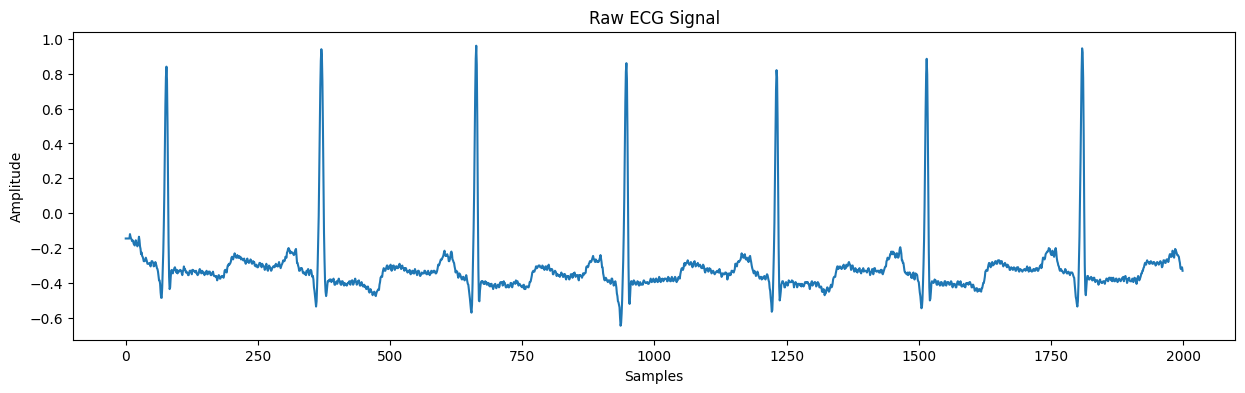

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000])
plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Plot R-Peak Annotations

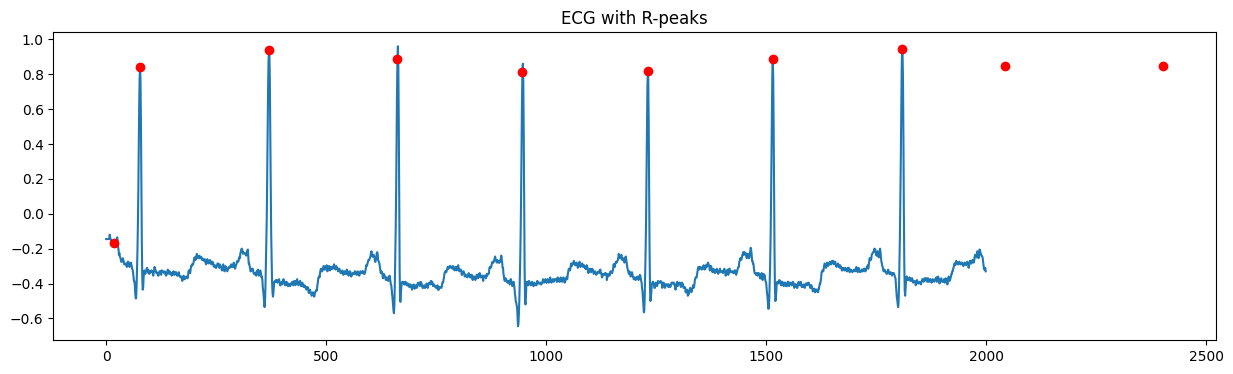

In [ ]:
r_peaks = annotation.sample

plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000])
plt.plot(r_peaks[:10], ecg_signal[r_peaks[:10]], "ro")
plt.title("ECG with R-peaks")
plt.show()

Check Beat Labels

In [ ]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


Convert Original Labels → AAMI Classes

In [ ]:
# AAMI label mapping
def map_label(label):
    if label in ['N', 'L', 'R']:
        return 'N'
    elif label in ['A', 'a', 'J', 'S']:
        return 'S'
    elif label in ['V', 'E']:
        return 'V'
    elif label == 'F':
        return 'F'
    else:
        return 'Q'

labels = annotation.symbol
mapped_labels = [map_label(l) for l in labels]

print(mapped_labels[:20])

['Q', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


Apply ECG Filtering (Noise Removal)


In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal_data, lowcut=0.5, highcut=40, fs=360, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal_data)
    return filtered


filtered_ecg = bandpass_filter(ecg_signal)

Visualize before vs after


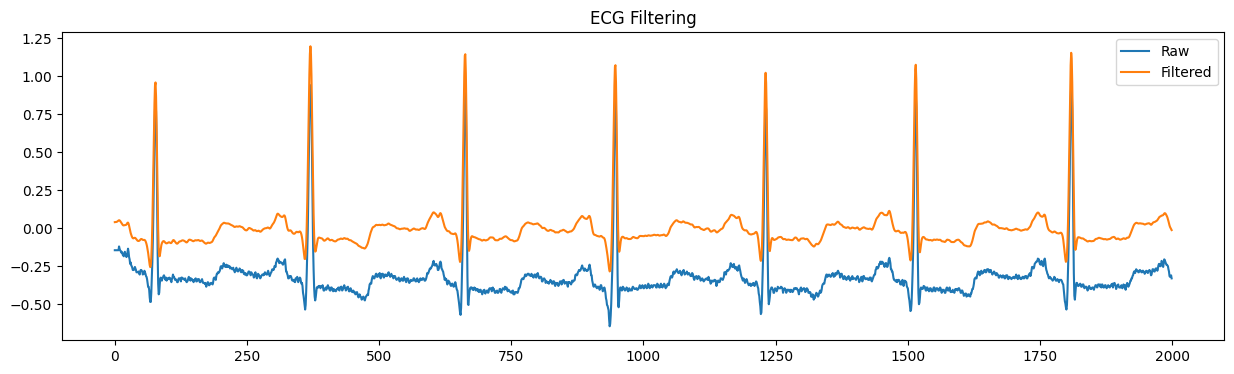

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000], label='Raw')
plt.plot(filtered_ecg[:2000], label='Filtered')
plt.legend()
plt.title("ECG Filtering")
plt.show()

Heartbeat Segmentation

In [ ]:
r_peaks = annotation.sample

beats = []
beat_labels = []

for i in range(len(r_peaks)):
    r = r_peaks[i]

    start = r - 180
    end = r + 180

    # Skip invalid segments
    if start < 0 or end > len(filtered_ecg):
        continue

    beat = filtered_ecg[start:end]

    # Ensure correct size
    if len(beat) == 360:
        beats.append(beat)
        beat_labels.append(mapped_labels[i])

Convert to NumPy Array

In [ ]:
import numpy as np

X = np.array(beats)
y = np.array(beat_labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2271, 360)
Shape of y: (2271,)


Normalize the Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize each beat individually
X_normalized = np.array([scaler.fit_transform(b.reshape(-1,1)).flatten() for b in X])

Encode Labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['N' 'S' 'V']


Reshape for Deep Learning

In [ ]:
X_final = X_normalized.reshape(X_normalized.shape[0], 360, 1)

print("Final shape:", X_final.shape)

For  all 48 recordings.

In [ ]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# All 48 records
records = [
'100','101','102','103','104','105','106','107','108','109',
'111','112','113','114','115','116','117','118','119','121',
'122','123','124',
'200','201','202','203','205','207','208','209','210',
'212','213','214','215','217','219','220','221','222','223',
'228','230','231','232','233','234'
]

# Label mapping
def map_label(label):
    if label in ['N', 'L', 'R']:
        return 'N'
    elif label in ['A', 'a', 'J', 'S']:
        return 'S'
    elif label in ['V', 'E']:
        return 'V'
    elif label == 'F':
        return 'F'
    else:
        return 'Q'

# Bandpass filter
def bandpass_filter(signal_data, lowcut=0.5, highcut=40, fs=360, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal_data)

all_beats = []
all_labels = []

# Loop through all records
for rec in records:
    print(f"Processing record {rec}...")

    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    ecg_signal = record.p_signal[:,0]
    filtered_ecg = bandpass_filter(ecg_signal)

    r_peaks = annotation.sample
    labels = annotation.symbol

    for i in range(len(r_peaks)):
        r = r_peaks[i]
        start = r - 180
        end = r + 180

        if start < 0 or end > len(filtered_ecg):
            continue

        beat = filtered_ecg[start:end]

        if len(beat) == 360:
            all_beats.append(beat)
            all_labels.append(map_label(labels[i]))

# Convert to arrays
X = np.array(all_beats)
y = np.array(all_labels)

print("Total beats:", X.shape)

# Normalize
scaler = MinMaxScaler()
X = np.array([scaler.fit_transform(b.reshape(-1,1)).flatten() for b in X])

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Reshape
X = X.reshape(X.shape[0], 360, 1)

print("Final shape:", X.shape)

Processing record 100...
Processing record 101...
Processing record 102...
Processing record 103...
Processing record 104...
Processing record 105...
Processing record 106...
Processing record 107...
Processing record 108...
Processing record 109...
Processing record 111...
Processing record 112...
Processing record 113...
Processing record 114...
Processing record 115...
Processing record 116...
Processing record 117...
Processing record 118...
Processing record 119...
Processing record 121...
Processing record 122...
Processing record 123...
Processing record 124...
Processing record 200...
Processing record 201...
Processing record 202...
Processing record 203...
Processing record 205...
Processing record 207...
Processing record 208...
Processing record 209...
Processing record 210...
Processing record 212...
Processing record 213...
Processing record 214...
Processing record 215...
Processing record 217...
Processing record 219...
Processing record 220...
Processing record 221...


In [ ]:
np.save('X_ecg.npy', X)
np.save('y_ecg.npy', y)

In [ ]:
from google.colab import files
files.download('X_ecg.npy')
files.download('y_ecg.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>